In [1]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import LineString
import osmnx as ox
import networkx as nx
import ast
from shapely import wkt

TIME_INTERVAL = '1H'

# Load INRIX speed data and conversion data
inrix_df = pd.read_csv('../data/inrix/Hamilton-County-INRIX.csv')
conversion_df = pd.read_csv('../data/inrix/XD_Identification.csv')

desired_date = pd.Timestamp("2025-03-10 01:00:00").date()
inrix_df["measurement_tstamp"] = pd.to_datetime(inrix_df["measurement_tstamp"])
inrix_df = inrix_df[inrix_df["measurement_tstamp"].dt.date == desired_date]

In [2]:
od_df = pd.read_csv('../move_OD/Tennessee/Hamilton/2025-03-10_2025-03-10/lodes_combs/lodes_2025-03-10.csv')
routing_df = pd.read_csv('/home/rishav/move_od/routing/routing_df.csv')
census_depart_times_df = pd.read_csv('/home/rishav/move_od/move_OD/Tennessee/Hamilton/2025-03-10_2025-03-10/census_data/census_depart_times.csv')
county_lodes_adjusted_df = pd.read_csv('/home/rishav/move_od/move_OD/Tennessee/Hamilton/2025-03-10_2025-03-10/census_data/county_lodes_adjusted.csv', index_col=0)
travel_time_to_work_by_geoid = pd.read_csv('../move_OD/Tennessee/Hamilton/2025-03-10_2025-03-10/census_data/travel_time_to_work.csv', index_col=0)

In [3]:
county_lodes_adjusted_df = county_lodes_adjusted_df[county_lodes_adjusted_df['total_jobs'] > 0]

In [4]:
gen_df = pd.read_csv('/home/rishav/move_od/move_OD/Tennessee/Hamilton/2025-03-10_2025-03-10/lodes_combs/lodes_2025-03-10.csv')
gen_df = pd.read_csv('/home/rishav/move_od/routing/lp_calibrated_trips.csv')

gen_df['departure_datetime'] = pd.to_datetime(gen_df['departure_datetime'])
gen_df['departure_time_secs'] = gen_df['departure_datetime'].dt.hour * 3600 + gen_df['departure_datetime'].dt.minute * 60 + gen_df['departure_datetime'].dt.second

In [6]:
od_pairs = []
for _, row in od_df.iterrows():
    orig_dep = pd.Timestamp(row['departure_time'])
    # snap to 2‑hour bins
    dep_time = orig_dep.floor(TIME_INTERVAL)
    time_str = dep_time.strftime('%H:%M:%S')

    od_pairs.append({
        "origin_geoid":             row['h_geocode'],
        "destination_geoid":        row['w_geocode'],
        "origin":             (row['origin_loc_lat'], row['origin_loc_lon']),
        "destination":        (row['dest_loc_lat'], row['dest_loc_lon']),
        "departure_time":     pd.Timestamp(f"{desired_date} {time_str}"),
    })

In [7]:
hourly_inrix_df = (inrix_df
    .set_index('measurement_tstamp')
    .groupby('xd_id')
    .resample(TIME_INTERVAL)  # now resample every 30 minutes instead of hourly
    .agg({
        'speed': 'mean',
        'historical_average_speed': 'mean',
        'reference_speed': 'mean',
        'travel_time_minutes': 'mean',
        'confidence_score': 'mean',
        'cvalue': 'mean'
    })
    .reset_index()
)

# Format the result
hourly_inrix_df = hourly_inrix_df.round(2)  # Round to 2 decimal places

# Extract all unique hourly timestamps
all_hours = hourly_inrix_df["measurement_tstamp"].drop_duplicates().sort_values()

In [22]:
bin_names = [
    'under_5_minutes', '5_to_9_minutes', '10_to_14_minutes',
    '15_to_19_minutes', '20_to_24_minutes', '25_to_29_minutes',
    '30_to_34_minutes', '35_to_39_minutes', '40_to_44_minutes',
    '45_to_59_minutes', '60_to_89_minutes', '90_minutes_and_over'
]

In [23]:
import pandas as pd

def compare_od_distributions(gen_df, county_lodes_adjusted_df, 
                             origin_col='h_geocode', dest_col='w_geocode'):
    # Aggregate counts for each OD pair in both dataframes
    gen_od = gen_df.groupby([origin_col, dest_col]).size().reset_index(name='gen_count')
    county_lodes_adjusted_df = county_lodes_adjusted_df.rename({'h_geocode': 'origin_geoid', 'w_geocode': 'destination_geoid'}, axis=1)
    lodes_od = county_lodes_adjusted_df.groupby([origin_col, dest_col])['total_jobs'].sum().reset_index()
    lodes_od = lodes_od.rename(columns={'total_jobs': 'lodes_count'})
    
    # Merge on OD pairs
    merged = pd.merge(gen_od, lodes_od, on=[origin_col, dest_col], how='outer').fillna(0)
    
    # Normalize counts to proportions
    merged['gen_prop'] = merged['gen_count'] / merged['gen_count'].sum()
    merged['lodes_prop'] = merged['lodes_count'] / merged['lodes_count'].sum()
    merged['diff'] = merged['gen_prop'] - merged['lodes_prop']
    
    return merged

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from datetime import datetime, time
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap

def plot_departure_distributions(gen_df, census_df=None, output_path=None, mode='histogram', origin_col='h_geocode'):
    """
    Plot the distribution of departure times for each origin.
    
    Parameters:
    -----------
    gen_df : DataFrame
        DataFrame containing the OD pairs with departure times
    census_df : DataFrame, optional
        DataFrame containing the census departure time distributions
    output_path : str, optional
        Path to save the plots. If None, plots will be displayed.
    mode : str
        Visualization mode: 'histogram', 'heatmap', or 'comparison'
    """
    # Get unique origins
    origins = gen_df[origin_col].unique()
    
    if mode == 'histogram':
        # Create histograms for each origin
        n_geocodes = len(origins)
        n_cols = min(3, n_geocodes)
        n_rows = (n_geocodes + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
        if n_rows == 1 and n_cols == 1:
            axes = np.array([axes])
        axes = axes.flatten()
        
        for i, origin in enumerate(origins):
            if i < len(axes):
                # Filter data for this origin
                geocode_df = gen_df[gen_df[origin_col] == origin]
                
                # Convert departure_time_secs to hours for better visualization
                departure_hours = geocode_df['departure_time_secs'] / 3600
                
                # Create histogram
                axes[i].hist(
                    departure_hours, 
                    bins=24, 
                    range=(0, 24), 
                    alpha=0.7, 
                    color='steelblue',
                    edgecolor='black'
                )
                
                # Customize plot
                axes[i].set_title(f'origin: {origin}')
                axes[i].set_xlabel('Hour of Day')
                axes[i].set_ylabel('Number of Departures')
                axes[i].set_xticks(range(0, 25, 3))
                axes[i].grid(alpha=0.3)
                
                # Add count in title
                count = len(geocode_df)
                axes[i].set_title(f'origin: {origin} (n={count})')
        
        # Hide unused subplots
        for j in range(i+1, len(axes)):
            axes[j].axis('off')
            
        plt.tight_layout()
        
    elif mode == 'heatmap':
        # Create a time-based heatmap
        plt.figure(figsize=(12, 8))
        
        # Prepare data for heatmap
        # Group by origin and hour
        gen_df['hour'] = gen_df['departure_time'].dt.hour
        heatmap_data = gen_df.groupby([origin_col, 'hour']).size().unstack(fill_value=0)
        
        # Normalize by row to show distribution percentages
        row_sums = heatmap_data.sum(axis=1)
        heatmap_data_norm = heatmap_data.div(row_sums, axis=0) * 100
        
        # Create custom colormap
        colors = ["#f7fbff", "#deebf7", "#c6dbef", "#9ecae1", "#6baed6", "#4292c6", "#2171b5", "#08519c", "#08306b"]
        cmap = LinearSegmentedColormap.from_list("custom_blues", colors)
        
        # Plot heatmap
        ax = sns.heatmap(
            heatmap_data_norm, 
            cmap=cmap, 
            annot=True, 
            fmt='.1f', 
            linewidths=.5,
            cbar_kws={'label': '% of Departures'}
        )
        
        # Customize plot
        ax.set_title('Departure Time Distribution by origin (% of total)')
        ax.set_xlabel('Hour of Day')
        ax.set_ylabel(origin_col)
        
    elif mode == 'comparison' and census_df is not None:
        # Compare generated distribution with census distribution
        n_geocodes = min(len(origins), 25)  # Limit to 9 plots
        n_cols = min(5, n_geocodes)
        n_rows = (n_geocodes + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
        if n_rows == 1 and n_cols == 1:
            axes = np.array([axes])
        axes = axes.flatten()
        
        # Time bins for census data (midpoints of the time ranges)
        # This will need customization based on the actual column names
        census_time_bins = {
            "12am_to_4:59am_estimate": 2.5,
            "5am_to_5:29am_estimate": 5.25,
            "5:30am_to_5:59am_estimate": 5.75,
            "6am_to_6:29am_estimate": 6.25,
            "6:30am_to_6:59am_estimate": 6.75,
            "7am_to_7:29am_estimate": 7.25,
            "7:30am_to_7:59am_estimate": 7.75,
            "8am_to_8:29am_estimate": 8.25,
            "8:30am_to_8:59am_estimate": 8.75,
            "9am_to_9:59am_estimate": 9.5,
            "10am_to_10:59am_estimate": 10.5,
            "11am_to_11:59am_estimate": 11.5,
            "12pm_to_3:59pm_estimate": 14.0,
            "4pm_to_11:59pm_estimate": 20.0
        }
        
        for i, origin in enumerate(origins[:n_geocodes]):
            # Filter generated data for this origin
            geocode_df = gen_df[gen_df[origin_col] == origin]
            departure_hours = geocode_df['departure_time_secs'] / 3600
            
            # Get census data for this origin
            census_row = census_df[census_df['GEO_ID'] == origin]
            
            # Plot generated distribution
            ax = axes[i]
            hist_values, bins, _ = ax.hist(
                departure_hours, 
                bins=24, 
                range=(0, 24), 
                alpha=0.5, 
                color='steelblue',
                edgecolor='black',
                density=True,
                label='Generated'
            )
            
            # Plot census distribution if available
            if not census_row.empty:
                census_hours = []
                census_counts = []
                
                total = census_row['total_estimate'].values[0]
                if total > 0:
                    for col, hour_mid in census_time_bins.items():
                        if col in census_row.columns:
                            count = census_row[col].values[0]
                            census_hours.append(hour_mid)
                            census_counts.append(count / total)
                
                # Plot as step function to represent time bins
                if census_hours:
                    ax.step(
                        census_hours, 
                        census_counts, 
                        where='mid', 
                        color='red', 
                        linewidth=2, 
                        label='Census'
                    )
            
            # Customize plot
            ax.set_title(f'origin: {origin}')
            ax.set_xlabel('Hour of Day')
            ax.set_ylabel('Density')
            ax.set_xticks(range(0, 25, 3))
            ax.grid(alpha=0.3)
            ax.legend()
            
            # Add count in title
            count = len(geocode_df)
            ax.set_title(f'origin: {origin} (n={count})')
        
        # Hide unused subplots
        for j in range(i+1, len(axes)):
            axes[j].axis('off')
            
        plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, bbox_inches='tight', dpi=300)
    else:
        plt.show()

In [25]:
census_time_bins = [
    (0, 299),      # 12:00am - 4:59am
    (300, 329),    # 5:00am - 5:29am
    (330, 359),    # 5:30am - 5:59am
    (360, 389),    # 6:00am - 6:29am
    (390, 419),    # 6:30am - 6:59am
    (420, 449),    # 7:00am - 7:29am
    (450, 479),    # 7:30am - 7:59am
    (480, 509),    # 8:00am - 8:29am
    (510, 539),    # 8:30am - 8:59am
    (540, 599),    # 9:00am - 9:59am
    (600, 659),    # 10:00am - 10:59am
    (660, 719),    # 11:00am - 11:59am
    (720, 959),    # 12:00pm - 3:59pm
    (960, 1439),   # 4:00pm - 11:59pm
]
# Prepare bin edges for pd.cut
bin_edges = [b[0] for b in census_time_bins] + [census_time_bins[-1][1]+1]

In [26]:
from scipy.spatial.distance import jensenshannon

def compute_departure_time_distances(gen_df, census_df, 
                                     origin_col='h_geocode', 
                                     dest_col='w_geocode',
                                     time_col='departure_time',
                                     census_time_bins=None):
    """
    Compute Jensen-Shannon distance between generated and census departure time distributions
    for each origin (and optionally destination).
    """

    results = []
    for origin in gen_df[origin_col].unique():
        # Generated distribution
        gen_times = gen_df[gen_df[origin_col] == origin][time_col]
        if pd.api.types.is_datetime64_any_dtype(gen_times):
            gen_minutes = gen_times.dt.hour * 60 + gen_times.dt.minute
        else:
            gen_minutes = gen_times
        gen_hist, _ = np.histogram(gen_minutes, bins=bin_edges)
        gen_dist = gen_hist / gen_hist.sum() if gen_hist.sum() > 0 else np.zeros_like(gen_hist)
        
        # Census distribution
        census_row = census_df[census_df['GEO_ID'] == origin]
        if census_row.empty:
            continue
        census_counts = []
        for col in census_df.columns:
            if col.endswith('_estimate') and col != 'total_estimate':
                census_counts.append(census_row[col].values[0])
        census_counts = np.array(census_counts)
        census_dist = census_counts / census_counts.sum() if census_counts.sum() > 0 else np.zeros_like(census_counts)
        
        # Pad to same length if needed
        min_len = min(len(gen_dist), len(census_dist))
        js_dist = jensenshannon(gen_dist[:min_len], census_dist[:min_len])
        results.append({'origin': origin, 'js_distance': js_dist})
    
    return pd.DataFrame(results)

In [14]:
def plot_departure_time_histograms(gen_df, census_df, 
                                   origin_col='h_geocode', 
                                   time_col='departure_datetime',
                                   census_time_bins=None,
                                   max_origins=6):
    """
    Plot normalized generated and census departure time histograms for each origin.
    """
    if census_time_bins is None:
        census_time_bins = [
            (0, 299), (300, 329), (330, 359), (360, 389), (390, 419),
            (420, 449), (450, 479), (480, 509), (510, 539), (540, 599),
            (600, 659), (660, 719), (720, 959), (960, 1439),
        ]
    bin_edges = [b[0] for b in census_time_bins] + [census_time_bins[-1][1]+1]
    bin_labels = [f"{b[0]//60:02d}:{b[0]%60:02d}-{b[1]//60:02d}:{b[1]%60:02d}" for b in census_time_bins]

    origins = gen_df[origin_col].unique()[:max_origins]
    n = len(origins)
    fig, axes = plt.subplots(n, 1, figsize=(12, 4*n), sharex=True)

    if n == 1:
        axes = [axes]

    for i, origin in enumerate(origins):
        ax = axes[i]
        # Generated
        gen_times = gen_df[gen_df[origin_col] == origin][time_col]
        if pd.api.types.is_datetime64_any_dtype(gen_times):
            gen_minutes = gen_times.dt.hour * 60 + gen_times.dt.minute
        else:
            gen_minutes = gen_times
        gen_hist, _ = np.histogram(gen_minutes, bins=bin_edges)
        gen_hist = gen_hist / gen_hist.sum() if gen_hist.sum() > 0 else gen_hist

        # Census
        census_row = census_df[census_df['GEO_ID'] == origin]
        census_counts = []
        for col in census_df.columns:
            if col.endswith('_estimate') and col != 'total_estimate':
                census_counts.append(census_row[col].values[0] if not census_row.empty else 0)
        census_counts = np.array(census_counts)
        census_counts = census_counts / census_counts.sum() if census_counts.sum() > 0 else census_counts

        # Plot
        ax.bar(np.arange(len(bin_labels))-0.2, gen_hist, width=0.4, label='Generated', color='steelblue')
        ax.bar(np.arange(len(bin_labels))+0.2, census_counts, width=0.4, label='Census', color='orange')
        ax.set_title(f"Origin: {origin}")
        ax.set_ylabel("Proportion")
        ax.set_xticks(np.arange(len(bin_labels)))
        ax.set_xticklabels(bin_labels, rotation=45, ha='right')
        ax.legend()
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [15]:
def plot_overall_departure_time_histograms(gen_df, census_df,
                                           time_col='departure_datetime',
                                           census_time_bins=None):
    """
    Plot normalized generated and census departure time histograms aggregated over all origins.
    """
    if census_time_bins is None:
        census_time_bins = [
            (0, 299), (300, 329), (330, 359), (360, 389), (390, 419),
            (420, 449), (450, 479), (480, 509), (510, 539), (540, 599),
            (600, 659), (660, 719), (720, 959), (960, 1439),
        ]
    bin_edges = [b[0] for b in census_time_bins] + [census_time_bins[-1][1] + 1]
    bin_labels = [f"{b[0]//60:02d}:{b[0]%60:02d}-{b[1]//60:02d}:{b[1]%60:02d}" for b in census_time_bins]

    fig, ax = plt.subplots(1, 1, figsize=(12, 6))

    # Generated data - aggregated
    if pd.api.types.is_datetime64_any_dtype(gen_df[time_col]):
        all_gen_minutes = gen_df[time_col].dt.hour * 60 + gen_df[time_col].dt.minute
    else:
        all_gen_minutes = gen_df[time_col] # Assuming it's already in minutes if not datetime

    if not all_gen_minutes.empty:
        gen_hist, _ = np.histogram(all_gen_minutes, bins=bin_edges)
        gen_hist_normalized = gen_hist / gen_hist.sum() if gen_hist.sum() > 0 else np.zeros_like(gen_hist)
        ax.bar(np.arange(len(bin_labels)) - 0.2, gen_hist_normalized, width=0.4, label='Generated (Overall)', color='steelblue')
    else:
        ax.bar(np.arange(len(bin_labels)) - 0.2, np.zeros(len(bin_labels)), width=0.4, label='Generated (Overall) - No Data', color='lightgray')


    # Census data - aggregated
    aggregated_census_counts = np.zeros(len(census_time_bins))
    if not census_df.empty:
        for i, _bin in enumerate(census_time_bins):
            # Find the corresponding column name in census_df
            # This assumes census_df columns are named like 'B08302_002E', 'B08302_003E', etc.
            # and that these correspond to the order of census_time_bins.
            # You might need to adjust this logic based on your actual census_df column naming and structure.
            # For this example, I'll assume a simple mapping based on column order for *_estimate.
            estimate_cols = [col for col in census_df.columns if col.endswith('_estimate') and col != 'total_estimate']
            if i < len(estimate_cols):
                census_col_for_bin = estimate_cols[i] # This is a placeholder logic
                aggregated_census_counts[i] = census_df[census_col_for_bin].sum()
            else:
                # Handle cases where there are fewer census estimate columns than bins
                pass # Or log a warning

    if aggregated_census_counts.sum() > 0:
        census_hist_normalized = aggregated_census_counts / aggregated_census_counts.sum()
        ax.bar(np.arange(len(bin_labels)) + 0.2, census_hist_normalized, width=0.4, label='Census (Overall)', color='orange')
    else:
        ax.bar(np.arange(len(bin_labels)) + 0.2, np.zeros(len(bin_labels)), width=0.4, label='Census (Overall) - No Data', color='moccasin')


    # ax.set_title("Overall Departure Time Distribution Comparison")
    ax.set_ylabel("Proportion")
    ax.set_xlabel("Departure Time Bin")
    ax.set_xticks(np.arange(len(bin_labels)))
    ax.set_xticklabels(bin_labels, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

In [16]:
from scipy.spatial.distance import jensenshannon, euclidean, cityblock
from scipy.stats import entropy, wasserstein_distance

def compare_departure_distribution_metrics_df(
    gen_df, census_df, 
    origin_col='origin_geoid', 
    time_col='departure_time',
    census_time_bins=None
):
    if census_time_bins is None:
        census_time_bins = [
            (0, 299), (300, 329), (330, 359), (360, 389), (390, 419),
            (420, 449), (450, 479), (480, 509), (510, 539), (540, 599),
            (600, 659), (660, 719), (720, 959), (960, 1439),
        ]
    bin_edges = [b[0] for b in census_time_bins] + [census_time_bins[-1][1]+1]
    bin_labels = [f"{b[0]//60:02d}:{b[0]%60:02d}-{b[1]//60:02d}:{b[1]%60:02d}" for b in census_time_bins]

    origins = gen_df[origin_col].unique()
    records = []
    for origin in origins:
        # Generated
        gen_times = gen_df[gen_df[origin_col] == origin][time_col]
        if pd.api.types.is_datetime64_any_dtype(gen_times):
            gen_minutes = gen_times.dt.hour * 60 + gen_times.dt.minute
        else:
            gen_minutes = gen_times
        gen_hist, _ = np.histogram(gen_minutes, bins=bin_edges)
        gen_hist = gen_hist / gen_hist.sum() if gen_hist.sum() > 0 else gen_hist

        # Census
        census_row = census_df[census_df['GEO_ID'] == origin]
        census_counts = []
        for col in census_df.columns:
            if col.endswith('_estimate') and col != 'total_estimate':
                census_counts.append(census_row[col].values[0] if not census_row.empty else 0)
        census_counts = np.array(census_counts)
        census_counts = census_counts / census_counts.sum() if census_counts.sum() > 0 else census_counts

        # Pad to same length if needed
        min_len = min(len(gen_hist), len(census_counts))
        g = gen_hist[:min_len]
        c = census_counts[:min_len]

        # Add small epsilon to avoid log(0) in KL
        eps = 1e-12
        g_kl = g + eps
        c_kl = c + eps

        # Metrics
        js_dist = jensenshannon(g, c)
        l1_dist = cityblock(g, c)
        l2_dist = euclidean(g, c)
        kl_gc = entropy(g_kl, c_kl)  # KL(gen || census)
        kl_cg = entropy(c_kl, g_kl)  # KL(census || gen)
        # Wasserstein needs bin centers
        bin_centers = np.array([(b[0]+b[1])/2 for b in census_time_bins[:min_len]])
        wass_dist = wasserstein_distance(bin_centers, bin_centers, g, c)

        diff = 0
        for i, label in enumerate(bin_labels):
            g = gen_hist[i] if i < len(gen_hist) else 0
            c = census_counts[i] if i < len(census_counts) else 0
            diff += g-c

        records.append({
            "origin": origin,
            "diff": diff,
            "js_distance": js_dist,
            "l1_distance": l1_dist,
            "l2_distance": l2_dist,
            "kl_gen_census": kl_gc,
            "kl_census_gen": kl_cg,
            "wasserstein": wass_dist
        })
    return pd.DataFrame(records)

In [17]:
import numpy as np

def check_zero_bin_alignment(gen_df, census_df, 
                             origin_col='h_geocode', 
                             time_col='departure_datetime',
                             census_time_bins=None):
    """
    For each origin, check if the zero bins in gen_df and census_df are aligned.
    Returns a DataFrame with origin, zero_bin_match (True/False), and the indices of mismatched bins.
    """
    bin_edges = [b[0] for b in census_time_bins] + [census_time_bins[-1][1]+1]

    results = []
    for origin in gen_df[origin_col].unique():
        # Generated distribution
        gen_times = gen_df[gen_df[origin_col] == origin][time_col]
        if pd.api.types.is_datetime64_any_dtype(gen_times):
            gen_minutes = gen_times.dt.hour * 60 + gen_times.dt.minute
        else:
            gen_minutes = gen_times
        gen_hist, _ = np.histogram(gen_minutes, bins=bin_edges)
        gen_zeros = set(np.where(gen_hist == 0)[0])

        # Census distribution
        census_row = census_df[census_df['GEO_ID'] == origin]
        if census_row.empty:
            continue
        census_counts = []
        for col in census_df.columns:
            if col.endswith('_estimate') and col != 'total_estimate':
                census_counts.append(census_row[col].values[0])
        census_counts = np.array(census_counts)
        census_zeros = set(np.where(census_counts == 0)[0])

        # Compare
        zero_bin_match = gen_zeros == census_zeros
        mismatched_bins = sorted(list((gen_zeros ^ census_zeros)))
        results.append({
            'origin': origin,
            'zero_bin_match': zero_bin_match,
            'mismatched_zero_bins': mismatched_bins,
            'gen_zero_bins': sorted(list(gen_zeros)),
            'census_zero_bins': sorted(list(census_zeros))
        })
    return pd.DataFrame(results)

In [18]:
import pandas as pd

dep_tbl = census_depart_times_df.loc[:, ~census_depart_times_df.columns.duplicated()]
est_cols = [c for c in dep_tbl.columns if c.endswith("_estimate") and c != "total_estimate"]

dep_tbl = dep_tbl[["GEO_ID", "total_estimate", *est_cols]].set_index("GEO_ID")

dep_bin_names = est_cols
dep_to_idx = {name: i for i, name in enumerate(dep_bin_names)}

q_dict = {}
count = 0
for o, row in dep_tbl.iterrows():
    total = row["total_estimate"]
    if total > 0:
        q_dict[o] = {       
            dep_to_idx[col]: row[col] / total
            for col in dep_bin_names
            if row[col] > 0
        }
    else:
        q_dict[o] = {}
        count += 1

In [19]:
time_col = 'departure_datetime'
def floor_datetime_to_bin(dt, bin_edges):
    minutes = dt.hour * 60 + dt.minute
    idx = np.searchsorted(bin_edges, minutes, side='right') - 1
    lower = bin_edges[idx]
    hr, rem = divmod(lower, 60)
    return dt.replace(hour=hr, minute=rem, second=0, microsecond=0)

if pd.api.types.is_datetime64_any_dtype(gen_df[time_col]):
    gen_df['departure_time_bin'] = gen_df[time_col].apply(lambda dt: floor_datetime_to_bin(dt, bin_edges))
    

In [27]:
# Example usage:
distances_df = compute_departure_time_distances(gen_df, census_depart_times_df, origin_col='origin_geoid', dest_col='destination_geoid', time_col='departure_datetime', census_time_bins=census_time_bins)
print(distances_df.head())
print("Mean JS distance:", distances_df['js_distance'].mean())

         origin  js_distance
0  470650104322     0.002265
1  470650104323     0.003853
2  470650104324     0.002533
3  470650104325     0.010563
4  470650104326     0.003043
Mean JS distance: 0.0038917783630429913


In [28]:
# Example usage:
zero_alignment_df = check_zero_bin_alignment(gen_df, census_depart_times_df, origin_col='origin_geoid', census_time_bins=census_time_bins)
print(zero_alignment_df[zero_alignment_df['zero_bin_match'] == False].head())
print(f"Fraction of origins with perfect zero-bin alignment: {zero_alignment_df['zero_bin_match'].mean():.2f}")

Empty DataFrame
Columns: [origin, zero_bin_match, mismatched_zero_bins, gen_zero_bins, census_zero_bins]
Index: []
Fraction of origins with perfect zero-bin alignment: 1.00


In [29]:
def check_destination_geoids_match(gen_df, lodes_df):
    """
    Check if the exact set of destination geoids for each origin matches 
    between generated data and LODES data.
    """
    results = []
    
    # Get all origins that appear in both datasets
    gen_origins = set(gen_df['origin_geoid'].unique())
    lodes_origins = set(lodes_df['h_geocode'].unique())
    common_origins = gen_origins.intersection(lodes_origins)
    
    print(f"Origins in gen_df: {len(gen_origins)}")
    print(f"Origins in lodes_df: {len(lodes_origins)}")
    print(f"Common origins: {len(common_origins)}")
    
    for origin in common_origins:
        # Get destination sets for this origin
        gen_destinations = set(gen_df[gen_df['origin_geoid'] == origin]['destination_geoid'].unique())
        lodes_destinations = set(lodes_df[lodes_df['h_geocode'] == origin]['w_geocode'].unique())
        
        # Check if sets are identical
        exact_match = gen_destinations == lodes_destinations
        
        # Calculate differences
        only_in_gen = gen_destinations - lodes_destinations
        only_in_lodes = lodes_destinations - gen_destinations
        
        results.append({
            'origin': origin,
            'gen_num_destinations': len(gen_destinations),
            'lodes_num_destinations': len(lodes_destinations),
            'exact_match': exact_match,
            'destinations_only_in_gen': len(only_in_gen),
            'destinations_only_in_lodes': len(only_in_lodes),
            'jaccard_similarity': len(gen_destinations.intersection(lodes_destinations)) / len(gen_destinations.union(lodes_destinations)) if gen_destinations.union(lodes_destinations) else 1.0,
            'only_in_gen_list': list(only_in_gen)[:5],  # First 5 for display
            'only_in_lodes_list': list(only_in_lodes)[:5]  # First 5 for display
        })
    
    return pd.DataFrame(results)

# Run the check
destination_match_results = check_destination_geoids_match(gen_df, county_lodes_adjusted_df)

print("=== DESTINATION GEOID EXACT MATCH CHECK ===")
print(f"Total origins analyzed: {len(destination_match_results)}")
print(f"Origins with exact destination match: {destination_match_results['exact_match'].sum()}")
print(f"Percentage with exact match: {destination_match_results['exact_match'].mean()*100:.1f}%")
print(f"Mean Jaccard similarity: {destination_match_results['jaccard_similarity'].mean():.4f}")

print("\nSummary statistics:")
print(destination_match_results[['gen_num_destinations', 'lodes_num_destinations', 
                                'destinations_only_in_gen', 'destinations_only_in_lodes', 
                                'jaccard_similarity']].describe())

print("\nOrigins with mismatched destinations (worst 10):")
mismatched = destination_match_results[destination_match_results['exact_match'] == False].sort_values('jaccard_similarity')
print(mismatched[['origin', 'gen_num_destinations', 'lodes_num_destinations', 
                  'destinations_only_in_gen', 'destinations_only_in_lodes', 
                  'jaccard_similarity']].head(10))

Origins in gen_df: 269
Origins in lodes_df: 269
Common origins: 269
=== DESTINATION GEOID EXACT MATCH CHECK ===
Total origins analyzed: 269
Origins with exact destination match: 269
Percentage with exact match: 100.0%
Mean Jaccard similarity: 1.0000

Summary statistics:
       gen_num_destinations  lodes_num_destinations  destinations_only_in_gen  \
count            269.000000              269.000000                     269.0   
mean             101.791822              101.791822                       0.0   
std               21.082668               21.082668                       0.0   
min                8.000000                8.000000                       0.0   
25%               90.000000               90.000000                       0.0   
50%              103.000000              103.000000                       0.0   
75%              115.000000              115.000000                       0.0   
max              149.000000              149.000000                       0.0   


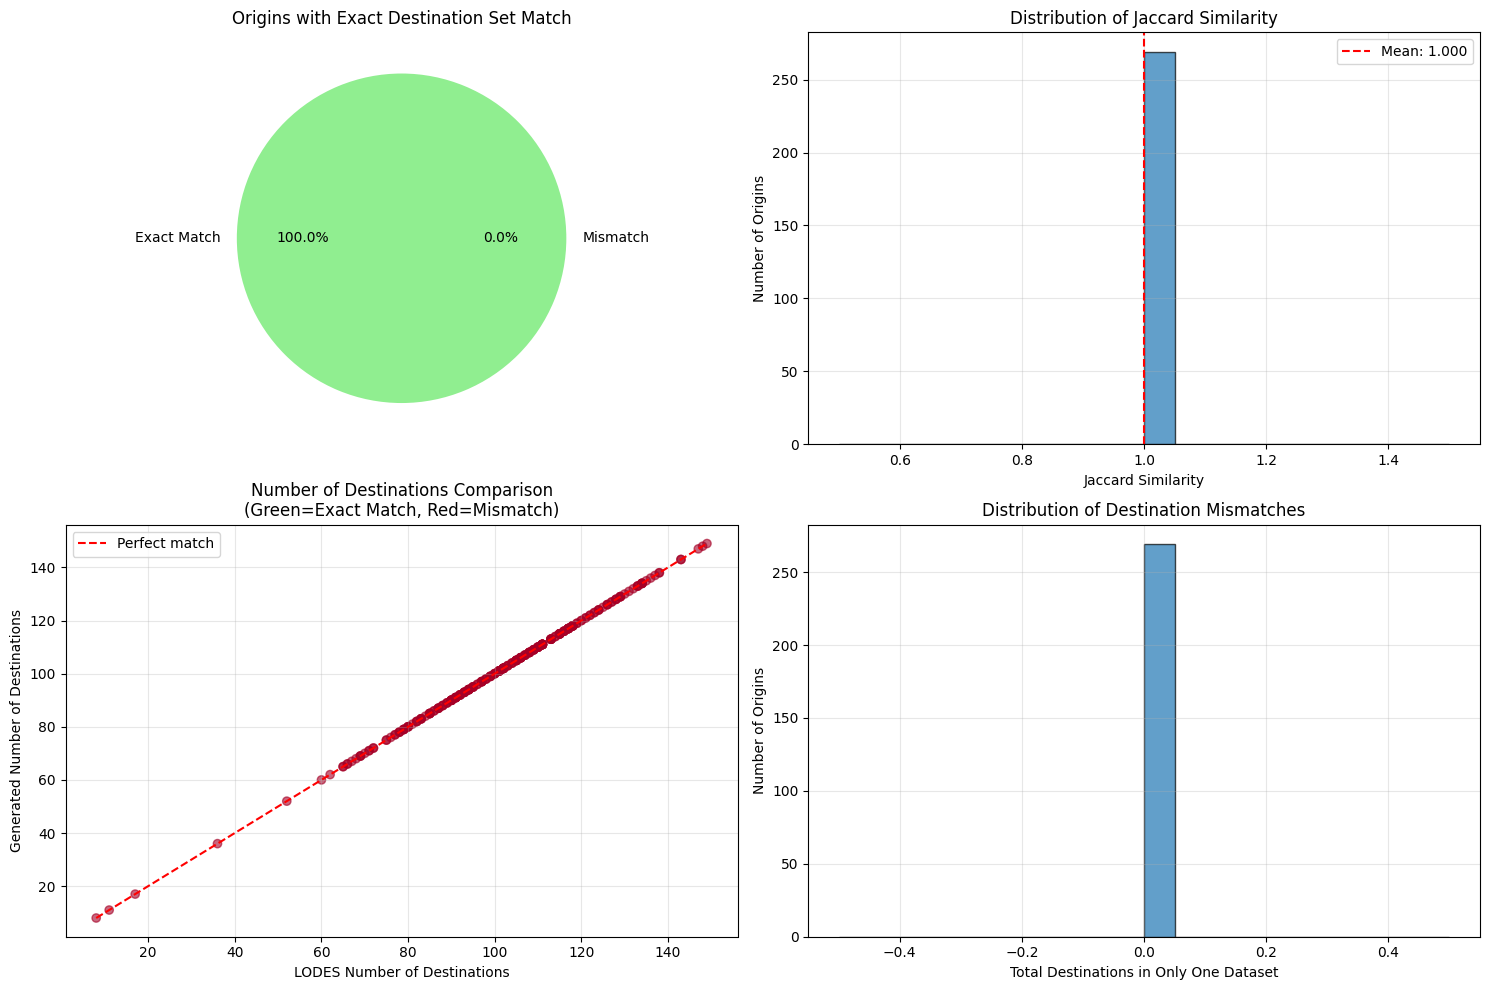

In [30]:
import matplotlib.pyplot as plt

def plot_destination_match_analysis(results_df):
    """Plot analysis of destination geoid matching"""
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    # Exact match pie chart
    exact_matches = results_df['exact_match'].sum()
    no_matches = len(results_df) - exact_matches
    ax1.pie([exact_matches, no_matches], labels=['Exact Match', 'Mismatch'], 
            autopct='%1.1f%%', colors=['lightgreen', 'lightcoral'])
    ax1.set_title('Origins with Exact Destination Set Match')
    
    # Jaccard similarity distribution
    ax2.hist(results_df['jaccard_similarity'], bins=20, alpha=0.7, edgecolor='black')
    ax2.set_xlabel('Jaccard Similarity')
    ax2.set_ylabel('Number of Origins')
    ax2.set_title('Distribution of Jaccard Similarity')
    ax2.axvline(results_df['jaccard_similarity'].mean(), color='red', linestyle='--',
                label=f'Mean: {results_df["jaccard_similarity"].mean():.3f}')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    # Number of destinations comparison
    ax3.scatter(results_df['lodes_num_destinations'], results_df['gen_num_destinations'], 
                alpha=0.6, c=results_df['exact_match'], cmap='RdYlGn')
    ax3.plot([results_df['lodes_num_destinations'].min(), results_df['lodes_num_destinations'].max()],
             [results_df['lodes_num_destinations'].min(), results_df['lodes_num_destinations'].max()],
             'r--', label='Perfect match')
    ax3.set_xlabel('LODES Number of Destinations')
    ax3.set_ylabel('Generated Number of Destinations')
    ax3.set_title('Number of Destinations Comparison\n(Green=Exact Match, Red=Mismatch)')
    ax3.legend()
    ax3.grid(alpha=0.3)
    
    # Destinations only in one dataset
    results_df['total_mismatches'] = results_df['destinations_only_in_gen'] + results_df['destinations_only_in_lodes']
    ax4.hist(results_df['total_mismatches'], bins=20, alpha=0.7, edgecolor='black')
    ax4.set_xlabel('Total Destinations in Only One Dataset')
    ax4.set_ylabel('Number of Origins')
    ax4.set_title('Distribution of Destination Mismatches')
    ax4.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Create the visualization
plot_destination_match_analysis(destination_match_results)

In [31]:
def create_destination_preservation_summary_table(destination_match_results):
    """Create a summary table for academic presentation"""
    
    summary_stats = {
        'Metric': [
            'Total Origins Analyzed',
            'Origins with Perfect Destination Match',
            'Perfect Match Rate (%)',
            'Mean Jaccard Similarity',
            'Median Jaccard Similarity', 
            'Min Jaccard Similarity',
            'Origins with Jaccard ≥ 0.95',
            'Origins with Jaccard ≥ 0.99',
            'Mean Destinations per Origin (Generated)',
            'Mean Destinations per Origin (LODES)',
            'Total OD Pairs Preserved (%)'
        ],
        'Value': [
            len(destination_match_results),
            destination_match_results['exact_match'].sum(),
            f"{destination_match_results['exact_match'].mean()*100:.1f}",
            f"{destination_match_results['jaccard_similarity'].mean():.4f}",
            f"{destination_match_results['jaccard_similarity'].median():.4f}",
            f"{destination_match_results['jaccard_similarity'].min():.4f}",
            f"{(destination_match_results['jaccard_similarity'] >= 0.95).sum()}",
            f"{(destination_match_results['jaccard_similarity'] >= 0.99).sum()}",
            f"{destination_match_results['gen_num_destinations'].mean():.1f}",
            f"{destination_match_results['lodes_num_destinations'].mean():.1f}",
            f"{((destination_match_results['gen_num_destinations'] * destination_match_results['jaccard_similarity']).sum() / destination_match_results['gen_num_destinations'].sum() * 100):.1f}"
        ]
    }
    
    return pd.DataFrame(summary_stats)

# Generate the table
summary_table = create_destination_preservation_summary_table(destination_match_results)
print("Table 1: Origin-Destination Structure Preservation Summary")
print("="*60)
print(summary_table.to_string(index=False))

Table 1: Origin-Destination Structure Preservation Summary
                                  Metric  Value
                  Total Origins Analyzed    269
  Origins with Perfect Destination Match    269
                  Perfect Match Rate (%)  100.0
                 Mean Jaccard Similarity 1.0000
               Median Jaccard Similarity 1.0000
                  Min Jaccard Similarity 1.0000
             Origins with Jaccard ≥ 0.95    269
             Origins with Jaccard ≥ 0.99    269
Mean Destinations per Origin (Generated)  101.8
    Mean Destinations per Origin (LODES)  101.8
            Total OD Pairs Preserved (%)  100.0


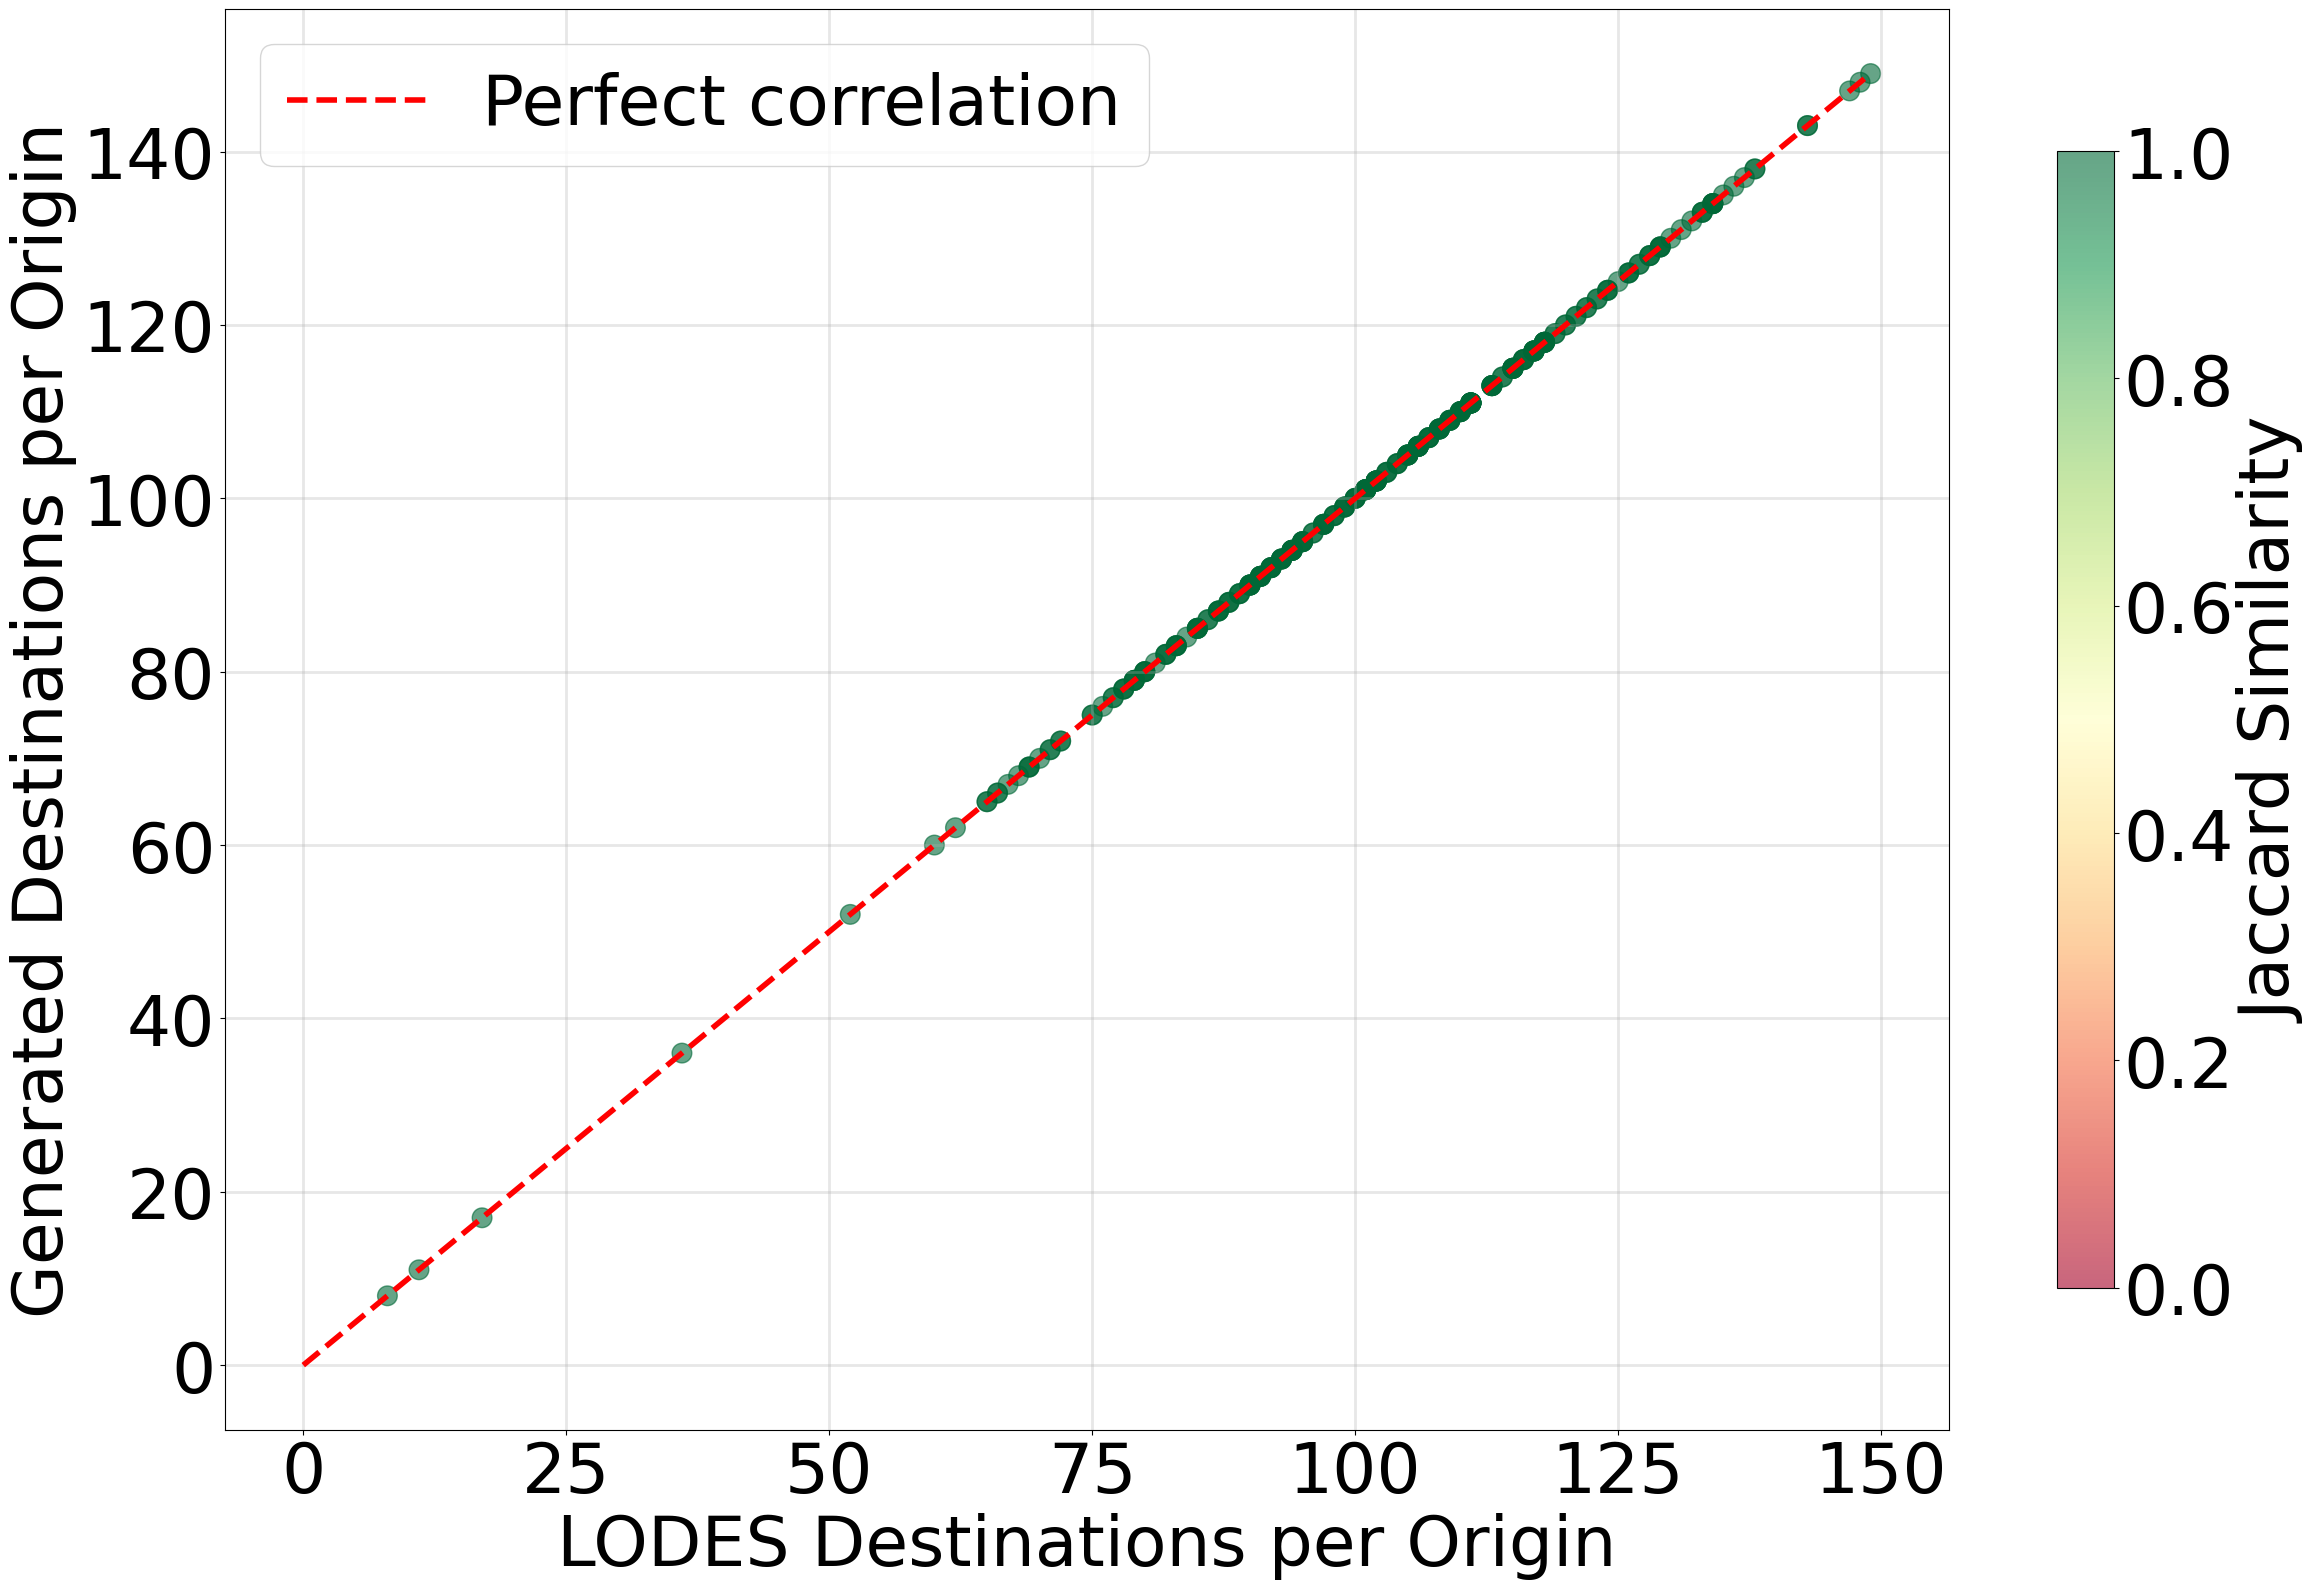

In [32]:
def plot_destination_count_preservation(destination_match_results):
    """Only Panel C: Generated vs LODES destination counts (4× bigger with larger fonts)"""
    # 4× the original 8×6 → 50×24
    fig, ax = plt.subplots(figsize=(24, 16))
    
    sc = ax.scatter(
        destination_match_results['lodes_num_destinations'],
        destination_match_results['gen_num_destinations'],
        c=destination_match_results['jaccard_similarity'],
        cmap='RdYlGn',
        vmin=0, vmax=1,
        alpha=0.6,
        s=200  # enlarge markers a bit
    )
    
    # perfect‐correlation line
    max_val = max(
        destination_match_results['lodes_num_destinations'].max(),
        destination_match_results['gen_num_destinations'].max()
    )
    ax.plot([0, max_val], [0, max_val], 'r--', linewidth=4, label='Perfect correlation')
    
    # axis labels & title with larger fonts
    ax.set_xlabel('LODES Destinations per Origin', fontsize= 50)
    ax.set_ylabel('Generated Destinations per Origin', fontsize= 50)
    # ax.set_title('Destination Count Preservation', fontsize=48)
    
    # tick labels
    ax.tick_params(axis='both', which='major', labelsize=50)
    
    # legend
    leg = ax.legend(fontsize=50)
    for text in leg.get_texts():
        text.set_fontsize(50)
    
    ax.grid(alpha=0.3, linewidth=2)
    
    # colorbar for Jaccard
    cbar = fig.colorbar(sc, ax=ax, shrink=0.8)
    cbar.ax.tick_params(labelsize=50)
    cbar.set_label('Jaccard Similarity', fontsize=50)
    
    plt.tight_layout()
    return fig

# draw it
fig = plot_destination_count_preservation(destination_match_results)
plt.show()


In [33]:
def analyze_specific_mismatch(origin_geoid, gen_df, lodes_df):
    """Analyze destination mismatch for a specific origin"""
    
    print(f"=== DETAILED ANALYSIS FOR ORIGIN {origin_geoid} ===")
    
    # Get destinations from both datasets
    gen_destinations = set(gen_df[gen_df['origin_geoid'] == origin_geoid]['destination_geoid'].unique())
    lodes_destinations = set(lodes_df[lodes_df['h_geocode'] == origin_geoid]['w_geocode'].unique())
    
    print(f"Generated destinations ({len(gen_destinations)}): {sorted(gen_destinations)}")
    print(f"LODES destinations ({len(lodes_destinations)}): {sorted(lodes_destinations)}")
    
    only_in_gen = gen_destinations - lodes_destinations
    only_in_lodes = lodes_destinations - gen_destinations
    common = gen_destinations.intersection(lodes_destinations)
    
    print(f"\nCommon destinations ({len(common)}): {sorted(common)}")
    print(f"Only in generated ({len(only_in_gen)}): {sorted(only_in_gen)}")
    print(f"Only in LODES ({len(only_in_lodes)}): {sorted(only_in_lodes)}")
    
    # Show trip/job counts for this origin
    gen_trips = gen_df[gen_df['origin_geoid'] == origin_geoid].groupby('destination_geoid').size()
    lodes_jobs = lodes_df[lodes_df['h_geocode'] == origin_geoid].groupby('w_geocode')['total_jobs'].sum()
    
    print(f"\nGenerated trip counts by destination:")
    print(gen_trips.sort_values(ascending=False))
    
    print(f"\nLODES job counts by destination:")
    print(lodes_jobs.sort_values(ascending=False))

# Analyze a few specific mismatched origins
if len(mismatched) > 0:
    # Analyze the worst mismatch
    worst_origin = mismatched.iloc[0]['origin']
    analyze_specific_mismatch(worst_origin, gen_df, county_lodes_adjusted_df)

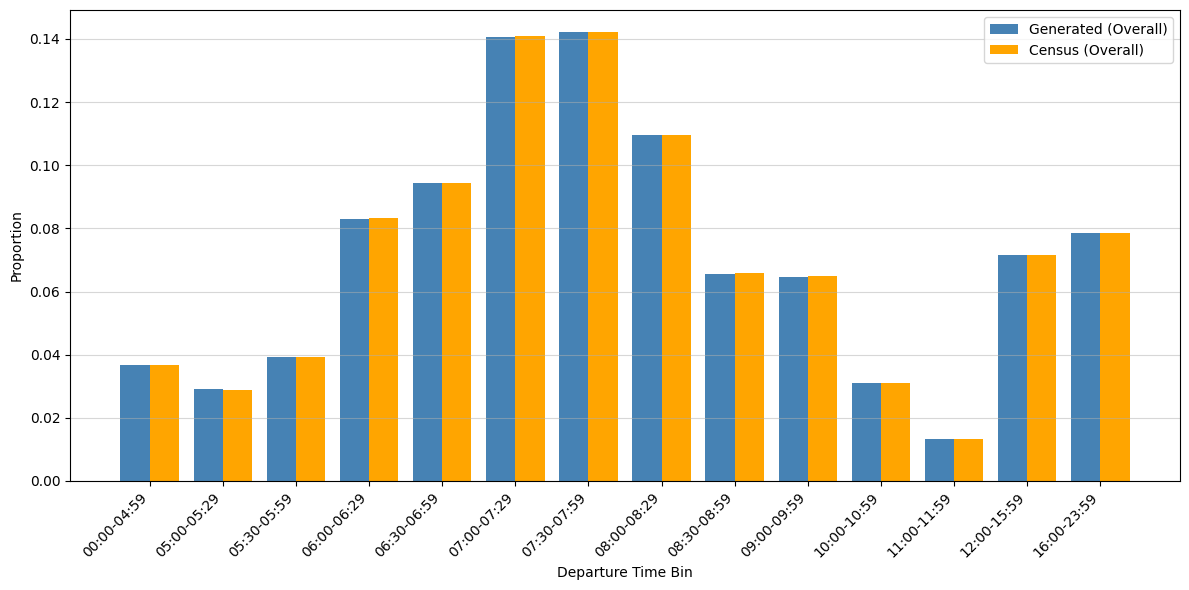

In [34]:
plot_overall_departure_time_histograms(gen_df, census_depart_times_df, 
                                   time_col='departure_datetime',
                                   census_time_bins=None)

In [ ]:
plot_departure_time_histograms(gen_df, census_depart_times_df, origin_col="origin_geoid")

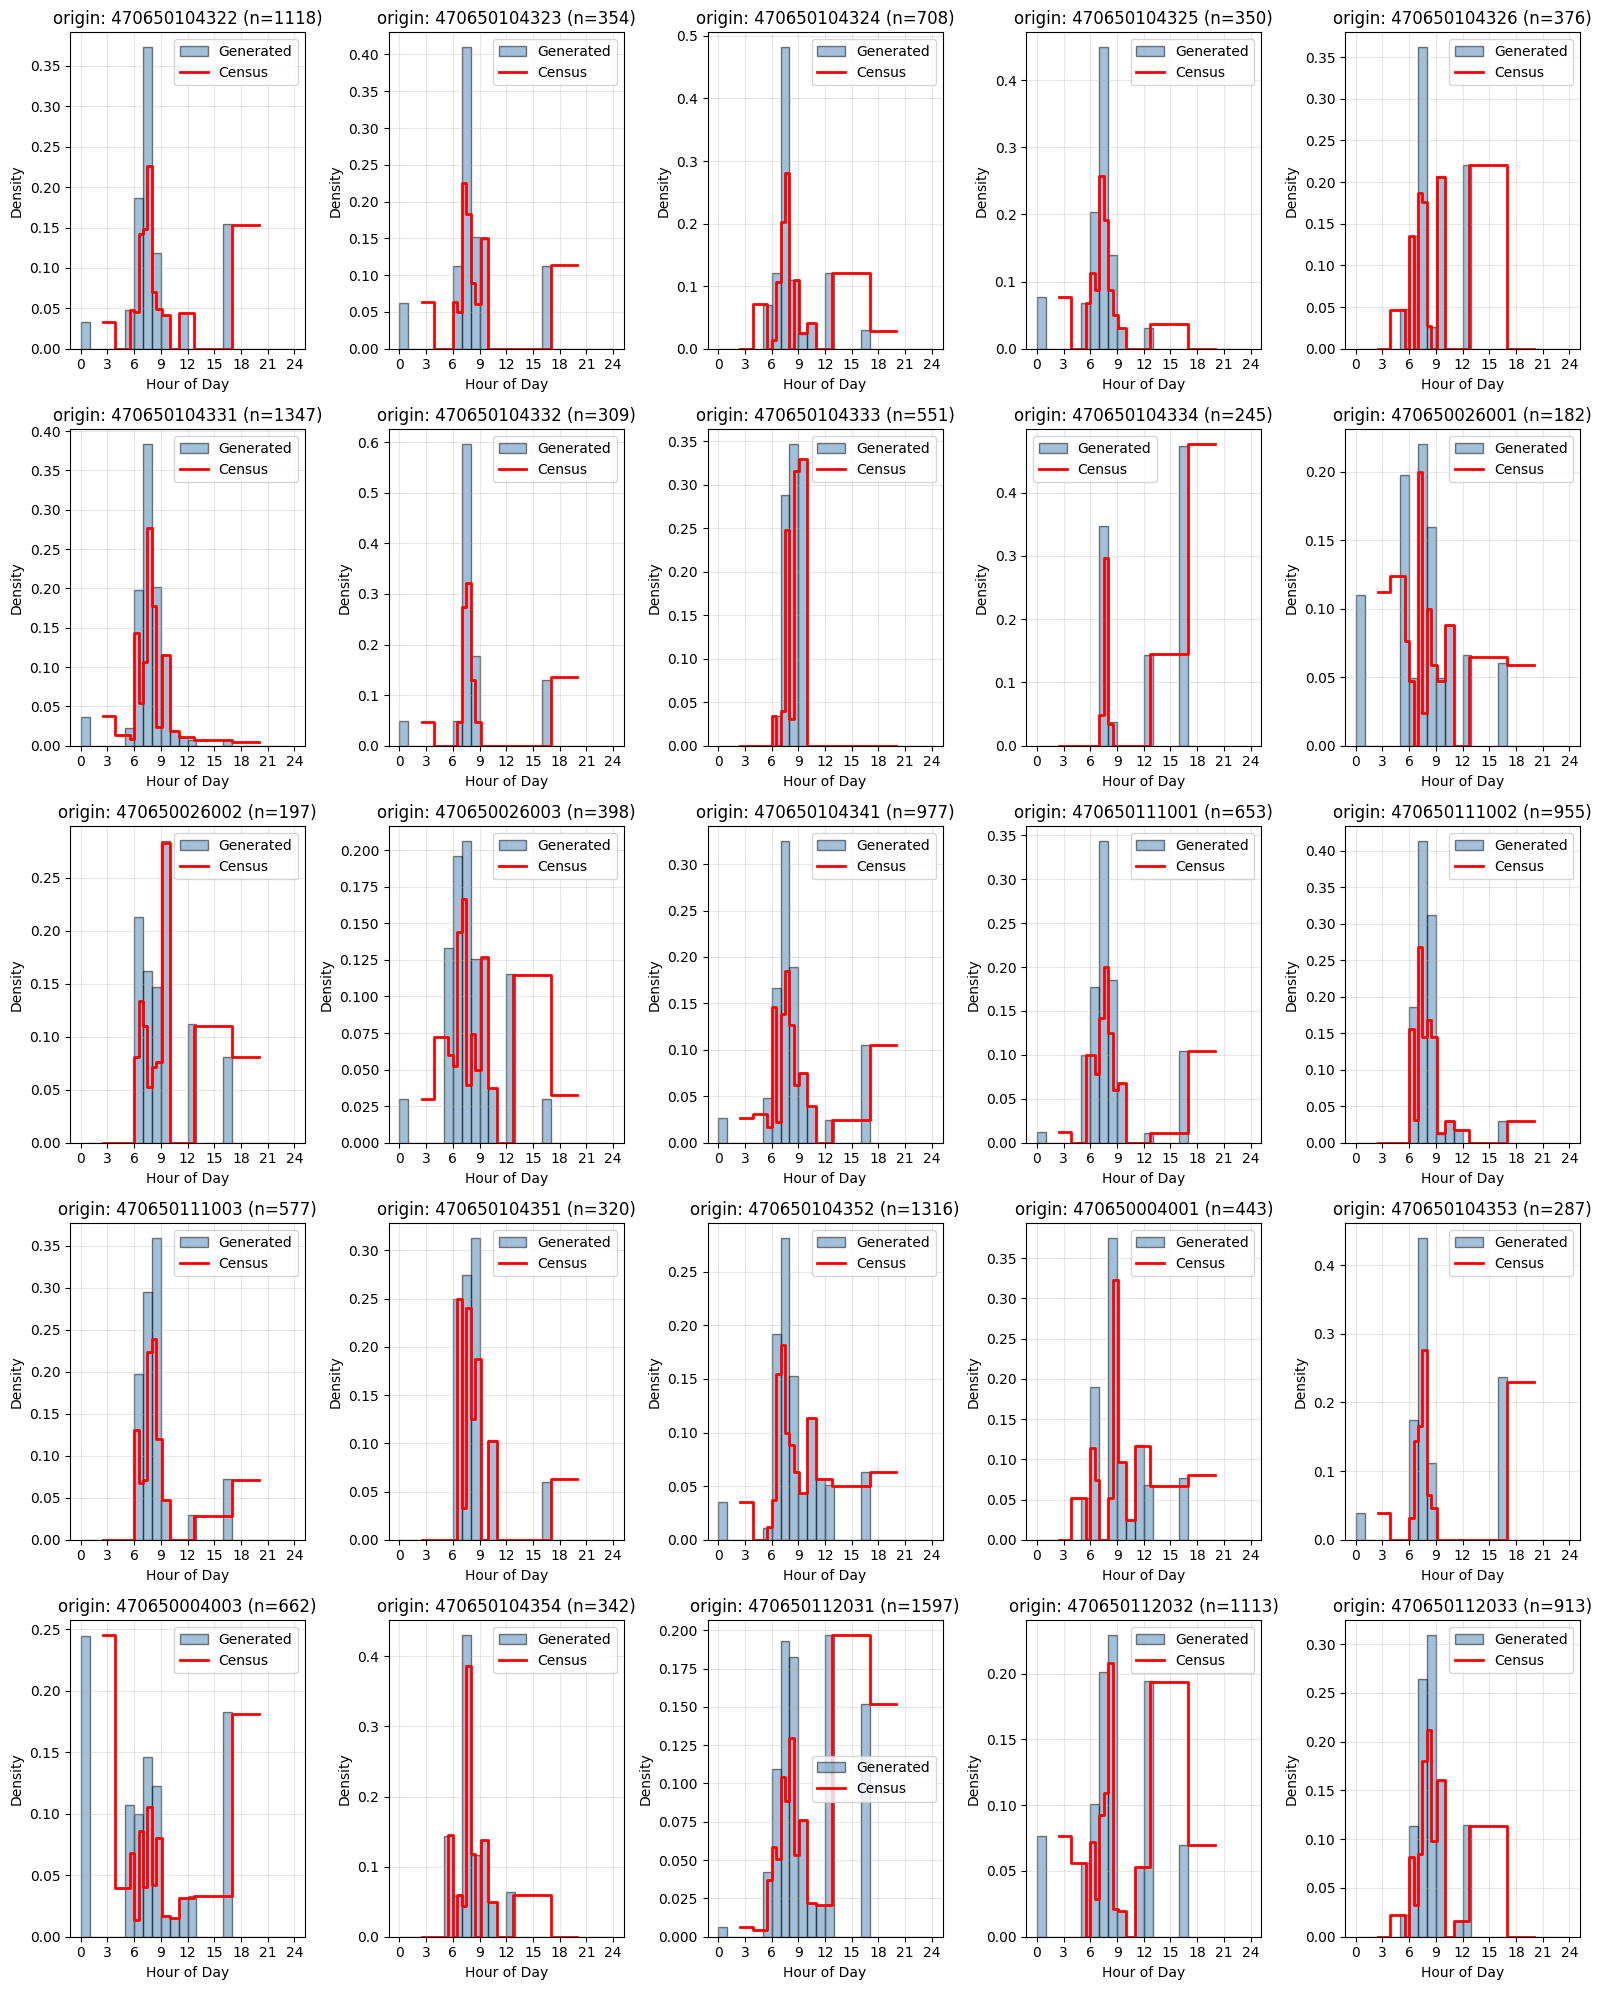

In [35]:
# plot_departure_distributions(gen_df, mode='histogram')
plot_departure_distributions(gen_df, census_depart_times_df, mode='comparison', origin_col='origin_geoid')

In [36]:
# Extract bin_labels from columns with 'estimate' (excluding 'total_estimate')
bin_labels = [
    col for col in travel_time_to_work_by_geoid.columns
    if 'estimate' in col and col != 'total_estimate'
]

# Try to extract the numeric ranges from the column names for travel_time_bins
import re

def parse_bin(col):
    # Example patterns: 'less_than_10_estimate', '10_to_14_estimate', '90_or_more_estimate'
    if col.startswith('under_'):
        high = int(re.findall(r'\d+', col)[0])
        return (0, high-1)
    elif '_to_' in col:
        nums = [int(x) for x in re.findall(r'\d+', col)]
        return (nums[0], nums[1])
    elif '_over' in col:
        low = int(re.findall(r'\d+', col)[0])
        return (low, 999)
    else:
        return None

travel_time_bins = [parse_bin(col) for col in bin_labels]

In [37]:
import pandas as pd
import numpy as np

def assign_travel_time_bin(minutes):
    for i, (low, high) in enumerate(travel_time_bins):
        if low <= minutes <= high+1:
            return bin_labels[i]
    return bin_labels[-1]

def get_travel_time_distribution(df, travel_time_col='travel_time_minutes'):
    # Assign bins
    df = df.copy()
    df['travel_time_bin'] = df[travel_time_col].apply(assign_travel_time_bin)
    # Count and normalize
    counts = df['travel_time_bin'].value_counts().reindex(bin_labels, fill_value=0)
    return counts / counts.sum()

# For synthetic calibrated OD
gen_dist = get_travel_time_distribution(gen_df, travel_time_col='travel_time_min')

# For original OD
orig_dist = get_travel_time_distribution(routing_df, travel_time_col='travel_time_min')

# For census (already binned)
census_counts = travel_time_to_work_by_geoid[bin_labels].sum()
census_dist = census_counts / census_counts.sum()

# Combine into a DataFrame for comparison
comparison_df = pd.DataFrame({
    'synthetic': gen_dist * 100,
    'original': orig_dist * 100,
    'census': census_dist * 100
})

print(comparison_df)

# Optionally, compute distance metrics (e.g., L1, JS)
from scipy.spatial.distance import jensenshannon, cityblock, euclidean

metrics = {
    'l1_synth_census': cityblock(gen_dist, census_dist),
    'js_synth_census': jensenshannon(gen_dist, census_dist),
    'l2_synth_census': euclidean(gen_dist, census_dist),
    'l1_orig_census': cityblock(orig_dist, census_dist),
    'js_orig_census': jensenshannon(orig_dist, census_dist),
    'l2_orig_census': euclidean(orig_dist, census_dist),
}
print(metrics)

                              synthetic   original     census
under_5_minutes_estimate       7.513286   8.578478   2.393521
5_to_9_minutes_estimate       13.997839  15.990384   9.456144
10_to_14_minutes_estimate     16.723854  18.987790  14.593228
15_to_19_minutes_estimate     17.277398  17.442905  20.986673
20_to_24_minutes_estimate     14.971596  14.563801  18.463227
25_to_29_minutes_estimate     10.291748  10.302398   8.485491
30_to_34_minutes_estimate      8.760655   6.813437  13.368400
35_to_39_minutes_estimate      4.693118   3.955842   2.767529
40_to_44_minutes_estimate      3.043228   2.017461   2.613006
45_to_59_minutes_estimate      2.485893   1.324730   4.057949
60_to_89_minutes_estimate      0.236962   0.022775   1.484046
90_minutes_and_over_estimate   0.004423   0.000000   1.330785
{'l1_synth_census': 0.31908307275505376, 'js_synth_census': 0.1532101549272406, 'l2_synth_census': 0.10559424091201272, 'l1_orig_census': 0.4023795945711376, 'js_orig_census': 0.1906976887124069

In [38]:
import pandas as pd

# Define the census departure time bins (in minutes since midnight)
dep_edges = [0, 5*60, 5*60+30, 6*60, 6*60+30, 7*60,
             7*60+30, 8*60, 8*60+30, 9*60, 10*60, 11*60,
             12*60, 16*60, 24*60]
dep_labels = list(range(len(dep_edges)-1))
dep_names = [
    "12am_to_4:59am", "5am_to_5:29am", "5:30am_to_5:59am",
    "6am_to_6:29am", "6:30am_to_6:59am", "7am_to_7:29am",
    "7:30am_to_7:59am", "8am_to_8:29am", "8:30am_to_8:59am",
    "9am_to_9:59am", "10am_to_10:59am", "11am_to_11:59am",
    "12pm_to_3:59pm", "4pm_to_11:59pm"
]

# Helper function to map times to census time bins using the same method as calibrating.ipynb
def get_census_time_bin(time):
    """Maps a pandas Timestamp to census time bin using the same method as calibration"""
    # Convert time to minutes since midnight
    mins = time.hour * 60 + time.minute
    
    # Find which bin it falls into (manual implementation of pd.cut for a single value)
    for i, edge in enumerate(dep_edges[1:]):
        if mins < edge:
            return dep_names[i]
    
    # Fallback (should not happen with proper bin edges)
    return dep_names[-1]

# Helper function that uses integer bin index instead of name
def get_census_time_bin_index(time):
    """Maps a pandas Timestamp to census time bin index (0-13)"""
    # Convert time to minutes since midnight
    mins = time.hour * 60 + time.minute
    
    # Find which bin it falls into
    for i, edge in enumerate(dep_edges[1:]):
        if mins < edge:
            return i
    
    # Fallback (should not happen with proper bin edges)
    return len(dep_names) - 1

In [39]:

# Helper function to get travel time bin based on census categories
def get_travel_time_bin(minutes):
    """Maps travel time in minutes to census travel time bin format"""
    if minutes < 5:
        return 'under_5_minutes'
    elif minutes < 10:
        return '5_to_9_minutes'
    elif minutes < 15:
        return '10_to_14_minutes'
    elif minutes < 20:
        return '15_to_19_minutes'
    elif minutes < 25:
        return '20_to_24_minutes'
    elif minutes < 30:
        return '25_to_29_minutes'
    elif minutes < 35:
        return '30_to_34_minutes'
    elif minutes < 40:
        return '35_to_39_minutes'
    elif minutes < 45:
        return '40_to_44_minutes'
    elif minutes < 60:
        return '45_to_59_minutes'
    elif minutes < 90:
        return '60_to_89_minutes'
    else:
        return '90_minutes_and_over'

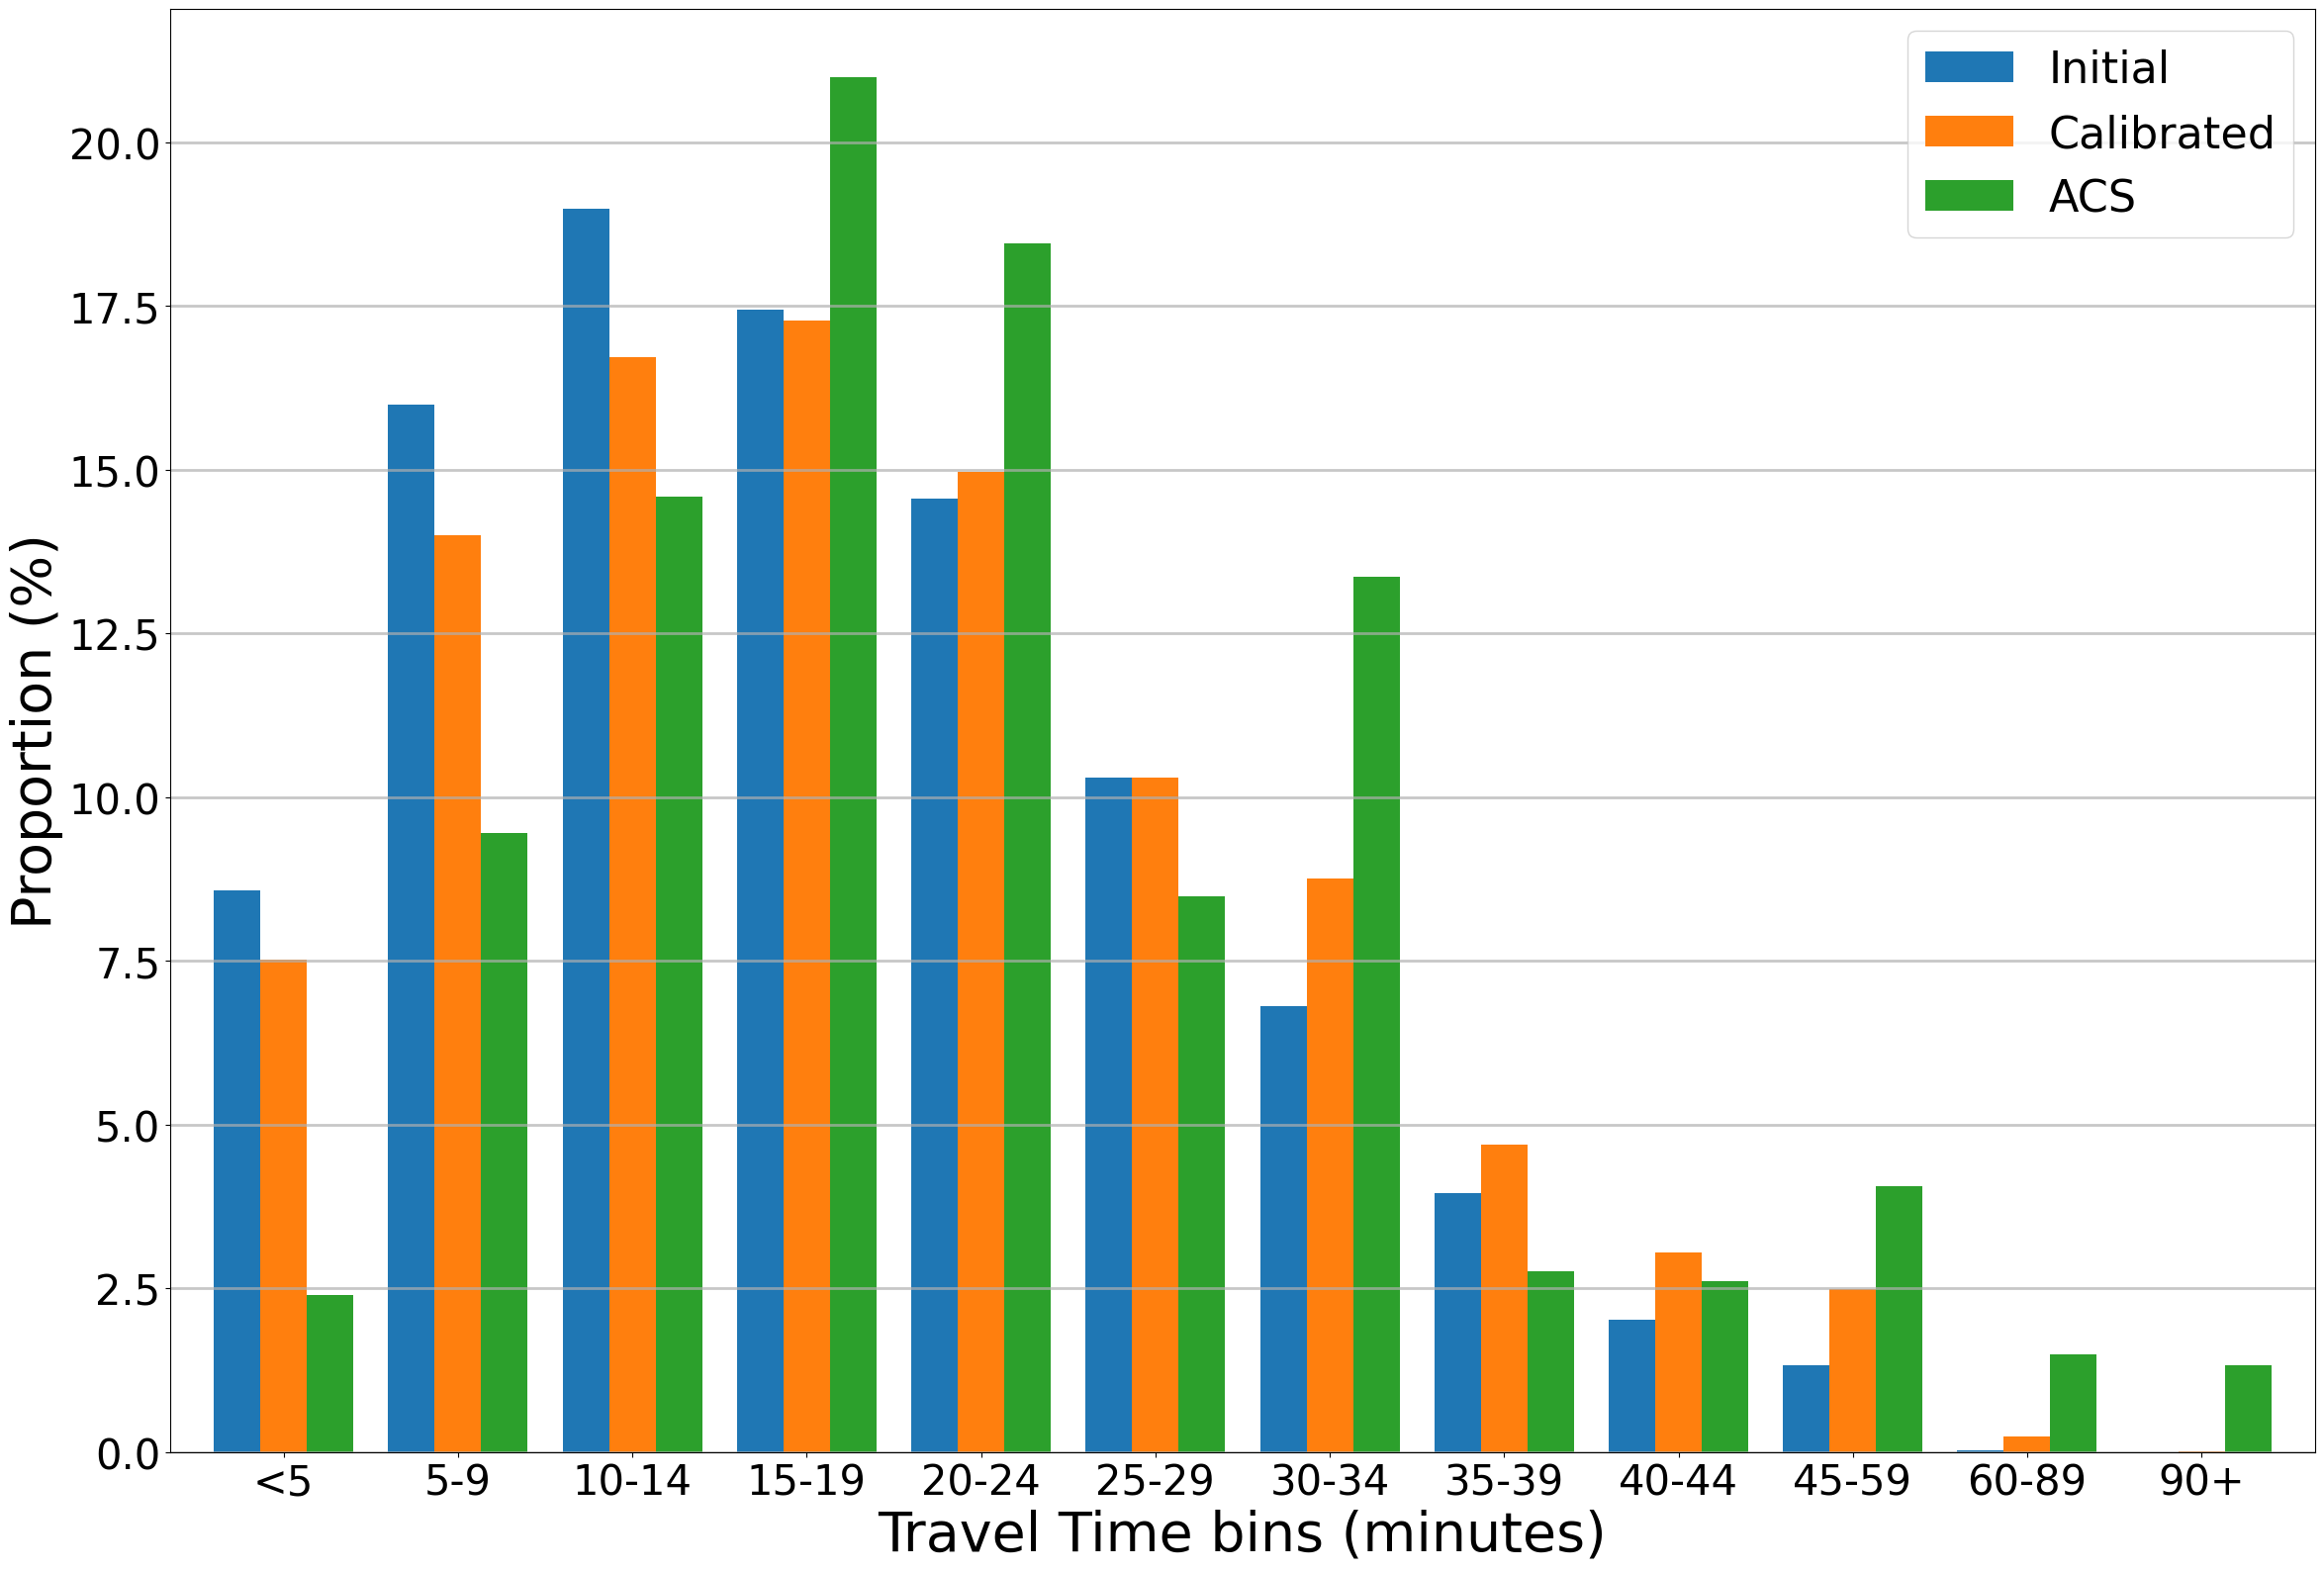

In [55]:
import matplotlib.pyplot as plt

# Create cleaner labels showing just the minute ranges
def create_minute_range_labels(bin_labels):
    """Convert column names to clean minute range labels"""
    clean_labels = []
    for label in bin_labels:
        if 'under_5' in label:
            clean_labels.append('<5')
        elif '5_to_9' in label:
            clean_labels.append('5-9')
        elif '10_to_14' in label:
            clean_labels.append('10-14')
        elif '15_to_19' in label:
            clean_labels.append('15-19')
        elif '20_to_24' in label:
            clean_labels.append('20-24')
        elif '25_to_29' in label:
            clean_labels.append('25-29')
        elif '30_to_34' in label:
            clean_labels.append('30-34')
        elif '35_to_39' in label:
            clean_labels.append('35-39')
        elif '40_to_44' in label:
            clean_labels.append('40-44')
        elif '45_to_59' in label:
            clean_labels.append('45-59')
        elif '60_to_89' in label:
            clean_labels.append('60-89')
        elif '90_minutes_and_over' in label:
            clean_labels.append('90+')
        else:
            clean_labels.append(label)  # fallback
    return clean_labels

# Ensure comparison_df index is bin_labels for correct order
comparison_df = comparison_df.reindex(bin_labels)
comparison_df = comparison_df[['original', 'synthetic', 'census']]

# Create the plot with much larger figure size
fig, ax = plt.subplots(figsize=(24, 16))  # Much larger figure

# Create the bar plot
bars = comparison_df.plot(
    kind='bar',
    ax=ax,
    color=['#1f77b4', '#ff7f0e', '#2ca02c'],  # blue, orange, green
    width=0.8
)

# Set clean labels with much larger font
clean_labels = create_minute_range_labels(bin_labels)
ax.set_xticklabels(clean_labels, rotation=0, ha='center', fontsize=30)

# Scale up all text elements
ax.set_xlabel("Travel Time bins (minutes)", fontsize=40)
ax.set_ylabel("Proportion (%)", fontsize=40)
# ax.set_title("Travel Time Distribution: Original, Synthetic (Calibrated), and Census", 
#              fontsize=48, fontweight='bold', pad=30)

# Scale up tick labels
ax.tick_params(axis='both', which='major', labelsize=30)

# Scale up legend
legend = ax.legend(["Initial", "Calibrated", "ACS"], fontsize=32, 
                   bbox_to_anchor=(0.8, 1), loc='upper left')

# Add grid lines for the y-axis with thicker lines
ax.yaxis.grid(True, linewidth=2, alpha=0.7)

# Annotate each bar with its height - much larger font
# for p in ax.patches:
#     height = p.get_height()
#     ax.annotate(f'{height:.1f}', 
#                 (p.get_x() + p.get_width() / 2, height+0.2),
#                 ha='center', va='bottom', 
#                 fontsize=20, rotation=90)

# Adjust layout to accommodate larger elements
plt.tight_layout()
plt.show()

In [115]:
import folium
import random
from folium.features import ColorLine
import numpy as np
from branca.colormap import LinearColormap

def get_curve_points(origin, destination, n_points=10, curvature=0.1):
    O = np.array(origin)
    D = np.array(destination)
    v = D - O
    norm_v = np.linalg.norm(v)
    if norm_v == 0:
        return [tuple(O)] * n_points
    # Midpoint
    M = (O + D) / 2
    # Perpendicular vector (rotate v 90°)
    perp = np.array([-v[1], v[0]])
    perp = perp / np.linalg.norm(perp)
    # Determine control point offset based on curvature factor
    offset = curvature * norm_v
    control = M + offset * perp
    # Compute points along quadratic Bézier curve:
    t_vals = np.linspace(0, 1, n_points)
    points = []
    for t in t_vals:
        pt = (1-t)**2 * O + 2*(1-t)*t*control + t**2 * D
        points.append(tuple(pt))
    return points

# Compute the center of the map using the average of all origins and destinations
all_lats = [od['origin'][0] for od in od_pairs] + [od['destination'][0] for od in od_pairs[:200]]
all_lons = [od['origin'][1] for od in od_pairs] + [od['destination'][1] for od in od_pairs[:200]]
center = [sum(all_lats) / len(all_lats), sum(all_lons) / len(all_lons)]

# Create a folium map centered at the computed center
m = folium.Map(location=center, zoom_start=10)

# Define a colormap that goes from green to red
colormap = LinearColormap(['green', 'red'], vmin=0, vmax=1)

# Sample OD pairs and plot curved lines between them
selected_od_pairs = random.sample(od_pairs, 1000)
for od in selected_od_pairs:
    origin = od['origin']
    destination = od['destination']
    points = get_curve_points(origin, destination, n_points=10, curvature=0.1)
    gradient = np.linspace(0, 1, len(points))
    ColorLine(positions=points, colors=gradient, colormap=colormap,
              weight=2, opacity=0.7).add_to(m)

m
